<a href="https://colab.research.google.com/github/karimullakhan9189/cifar10-resnet18-image-classifier/blob/main/Image_Classification_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Image Classification with Transfer Learning (ResNet-18)

This notebook trains a ResNet-18 model (pretrained on ImageNet) on the CIFAR-10 dataset using PyTorch.

**Pipeline overview:**
1. Load & augment CIFAR-10 (train/test split)
2. Load pretrained ResNet-18, replace final FC layer for 10 classes
3. Train for N epochs, tracking train loss + val accuracy per epoch
4. Plot training curves
5. Evaluate on test set — accuracy, classification report, confusion matrix
6. Save model weights and run inference on sample images

## 1. Install dependencies

In [2]:
# Run once if needed
# !pip install torch torchvision matplotlib seaborn scikit-learn

## 2. Imports

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import ResNet18_Weights

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

print(f"PyTorch version : {torch.__version__}")
print(f"Torchvision     : {torchvision.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device          : {device}")

PyTorch version : 2.11.0+cu128
Torchvision     : 0.26.0+cu128
Device          : cuda


## 3. Config

In [4]:

BATCH_SIZE   = 64
NUM_EPOCHS   = 10
LEARNING_RATE = 1e-3
NUM_WORKERS  = 2
NUM_CLASSES  = 10
MODEL_PATH   = 'resnet18_cifar10.pth'

CLASSES = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog',   'frog', 'horse', 'ship', 'truck')

## 4. Data Loading & Augmentation

- **Train**: random horizontal flip + random crop (standard CIFAR-10 augmentation) + normalization
- **Test** : only resize + normalization (no augmentation — we want a clean evaluation)

CIFAR-10 mean/std values are the channel-wise statistics computed over the full training set.

In [5]:

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=train_transform)

test_dataset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)

test_loader  = torch.utils.data.DataLoader(
    test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Training samples : {len(train_dataset):,}")
print(f"Test samples     : {len(test_dataset):,}")
print(f"Train batches    : {len(train_loader)}")
print(f"Test batches     : {len(test_loader)}")

100%|██████████| 170M/170M [00:28<00:00, 5.96MB/s]


Training samples : 50,000
Test samples     : 10,000
Train batches    : 782
Test batches     : 157


### 4.1 Visualise sample images

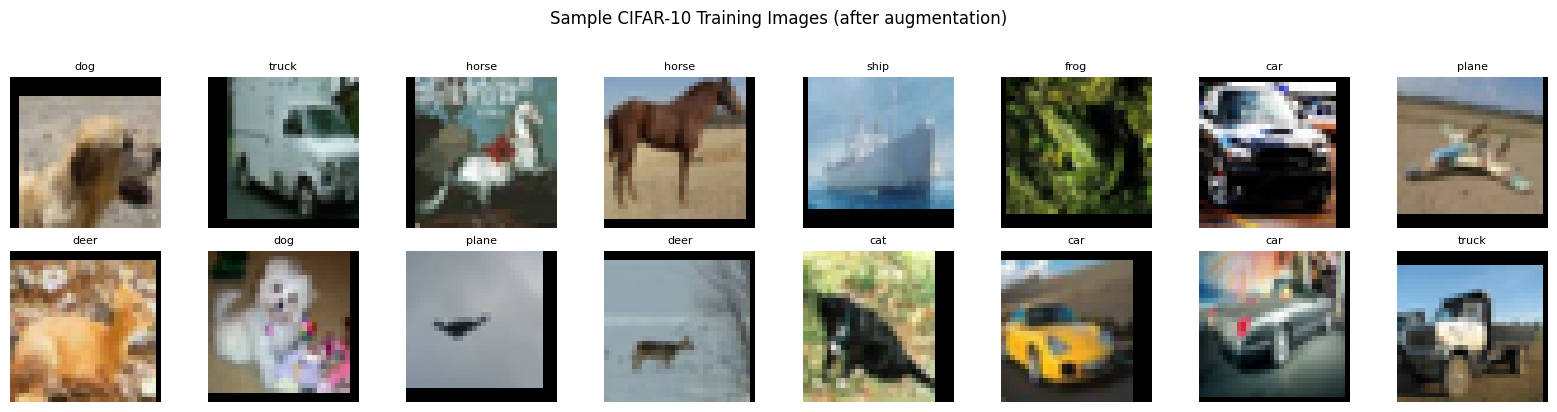

In [6]:
def denormalize(tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    """Reverse normalization for display."""
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Training Images (after augmentation)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Model — ResNet-18 with Transfer Learning

We load ImageNet-pretrained weights and replace only the final fully-connected layer to output 10 logits (one per CIFAR-10 class). All other layers are fine-tuned.

In [7]:

model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 219MB/s]

Total parameters    : 11,181,642
Trainable parameters: 11,181,642


## 6. Loss, Optimiser & Scheduler

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

## 7. Training Loop

Each epoch:
- Forward pass → compute loss → backward → optimiser step
- Record **average** train loss (per batch, not total sum)
- Record **validation accuracy** on the held-out test set  ← FIX: was using train set

In [9]:
def evaluate(loader, model, criterion):
    """Return average loss and accuracy on a DataLoader."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), 100.0 * correct / total


history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print(f"{'Epoch':>6}  {'Train Loss':>11}  {'Val Loss':>9}  {'Val Acc':>8}  {'LR':>10}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    val_loss, val_acc = evaluate(test_loader, model, criterion)
    scheduler.step()

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    current_lr = scheduler.get_last_lr()[0]
    print(f"{epoch:>6}  {avg_train_loss:>11.4f}  {val_loss:>9.4f}  {val_acc:>7.2f}%  {current_lr:>10.6f}")

print("\nTraining complete.")

 Epoch   Train Loss   Val Loss   Val Acc          LR
-------------------------------------------------------
     1       1.0986     0.8316    72.01%    0.000976
     2       0.8176     0.8062    71.91%    0.000905
     3       0.6969     0.6902    76.03%    0.000794
     4       0.6145     0.5751    80.55%    0.000655
     5       0.5399     0.5379    81.73%    0.000500
     6       0.4921     0.5449    82.06%    0.000345
     7       0.4295     0.4662    84.11%    0.000206
     8       0.3809     0.4715    84.58%    0.000095
     9       0.3377     0.4153    86.01%    0.000024
    10       0.3172     0.4142    86.22%    0.000000

Training complete.


## 8. Training Curves

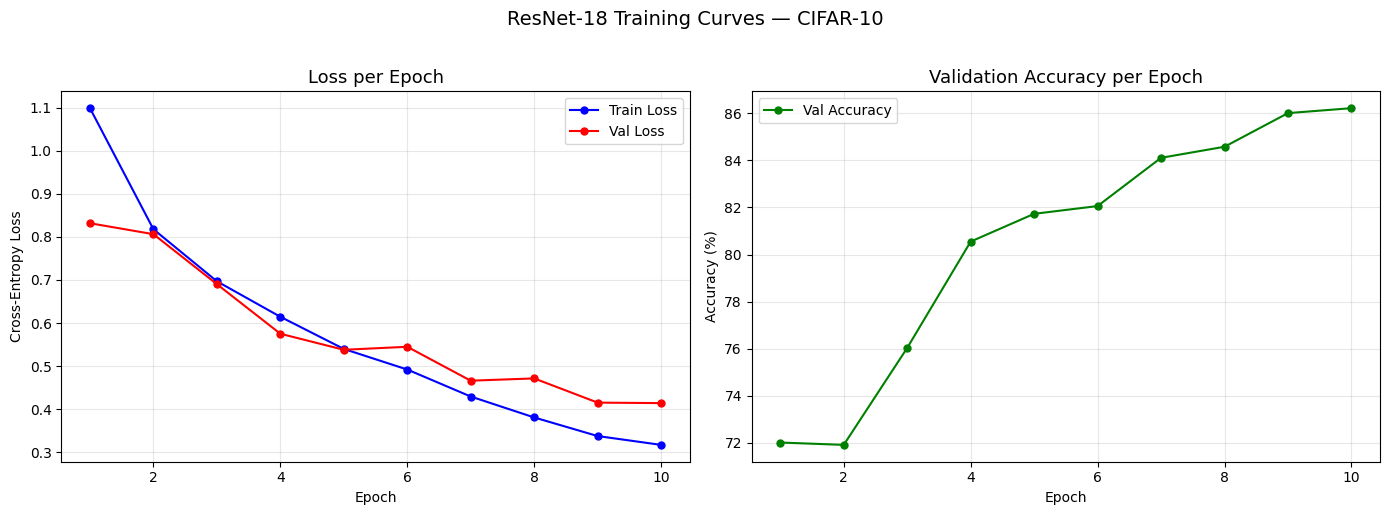

Best val accuracy: 86.22% at epoch 10


In [10]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=5)
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   markersize=5)
axes[0].set_title('Loss per Epoch', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['val_acc'], 'g-o', label='Val Accuracy', markersize=5)
axes[1].set_title('Validation Accuracy per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ResNet-18 Training Curves — CIFAR-10', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Best val accuracy: {max(history['val_acc']):.2f}% at epoch {history['val_acc'].index(max(history['val_acc'])) + 1}")

## 9. Evaluation — Classification Report & Confusion Matrix

In [11]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Classification Report")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=CLASSES))

Classification Report
              precision    recall  f1-score   support

       plane       0.86      0.91      0.88      1000
         car       0.95      0.91      0.93      1000
        bird       0.88      0.81      0.84      1000
         cat       0.72      0.69      0.71      1000
        deer       0.83      0.89      0.86      1000
         dog       0.76      0.78      0.77      1000
        frog       0.92      0.89      0.90      1000
       horse       0.90      0.89      0.89      1000
        ship       0.93      0.91      0.92      1000
       truck       0.89      0.93      0.91      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



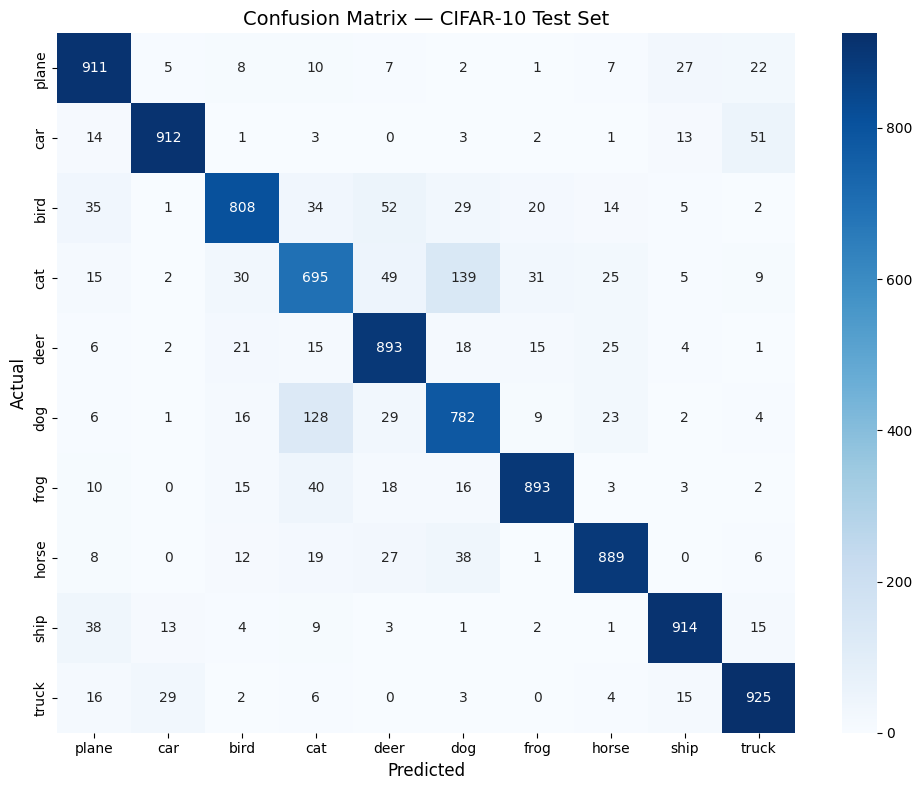

In [12]:

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual',    fontsize=12)
ax.set_title('Confusion Matrix — CIFAR-10 Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Save Model

In [13]:
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model weights saved → {MODEL_PATH}")

Model weights saved → resnet18_cifar10.pth


## 11. Inference on Sample Test Images

Reload weights from disk to verify the save/load cycle works correctly.

Model loaded from disk.


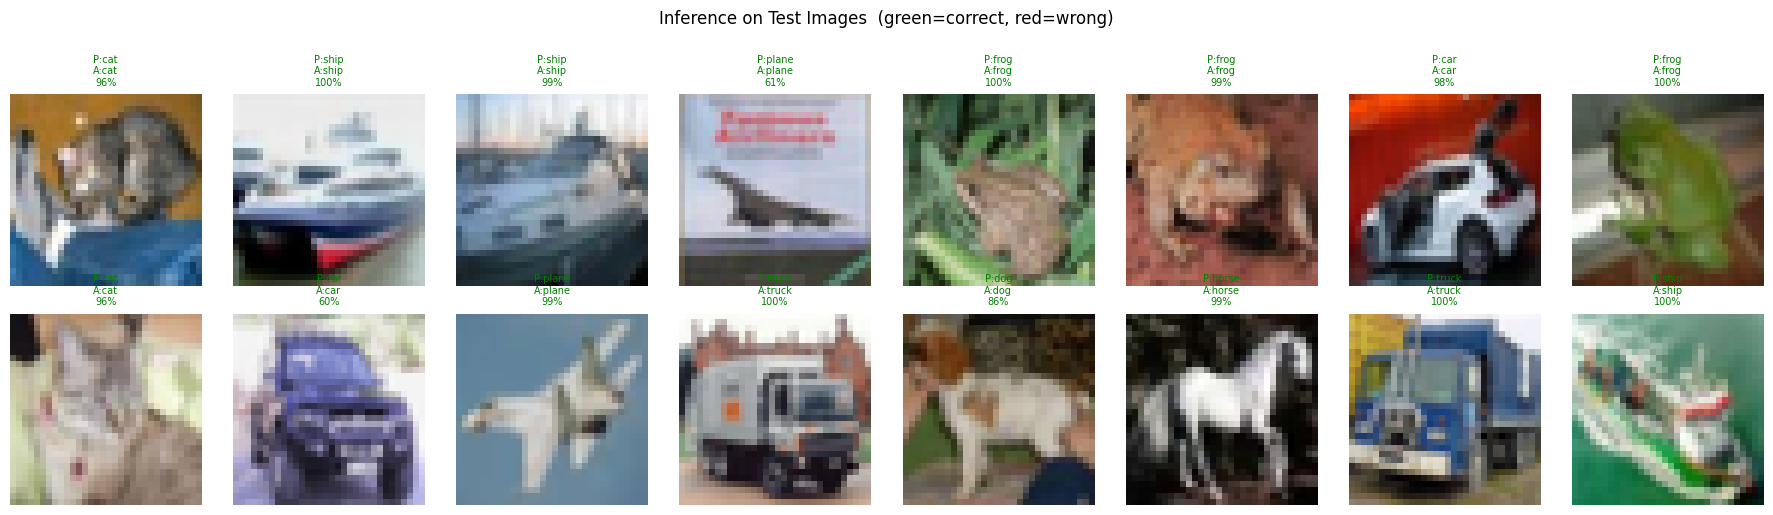

In [14]:

inference_model = models.resnet18(weights=None)
inference_model.fc = nn.Linear(512, NUM_CLASSES)
inference_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
inference_model = inference_model.to(device)
inference_model.eval()
print("Model loaded from disk.")

dataiter  = iter(test_loader)
images, labels = next(dataiter)
images_dev = images[:16].to(device)

with torch.no_grad():
    outputs   = inference_model(images_dev)
    probs     = torch.softmax(outputs, dim=1)
    conf, pred = probs.max(1)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    p_cls  = CLASSES[pred[i]]
    a_cls  = CLASSES[labels[i]]
    color  = 'green' if pred[i] == labels[i] else 'red'
    ax.set_title(f"P:{p_cls}\nA:{a_cls}\n{conf[i]*100:.0f}%",
                 fontsize=7, color=color)
    ax.axis('off')
plt.suptitle('Inference on Test Images  (green=correct, red=wrong)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('inference_samples.png', dpi=120, bbox_inches='tight')
plt.show()